Fitted model: T(n) ≈ 0.00000002 * n * log(n) + 0.00000215


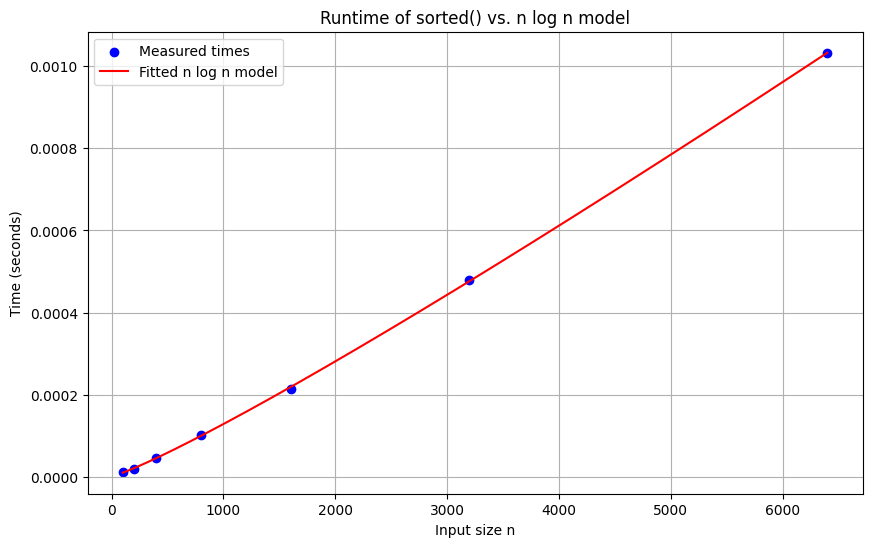

In [1]:
import numpy as np
import time
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import random

# Step 1: Define input sizes
input_sizes = [100, 200, 400, 800, 1600, 3200, 6400]

# Step 2: Measure the time for each size
times = []
for n in input_sizes:
    data = [random.random() for _ in range(n)]
    start = time.perf_counter()
    sorted_data = sorted(data)  # Python uses Timsort (n log n)
    end = time.perf_counter()
    times.append(end - start)

# Step 3: Define the model function: a * n * log(n) + b
def n_log_n_model(n, a, b):
    return a * n * np.log(n) + b

# Step 4: Fit the curve to the measured data
input_array = np.array(input_sizes)
time_array = np.array(times)
params, _ = curve_fit(n_log_n_model, input_array, time_array)
a_fit, b_fit = params

# Step 5: Print the result
print(f"Fitted model: T(n) ≈ {a_fit:.8f} * n * log(n) + {b_fit:.8f}")

# Step 6: Plot results
plt.figure(figsize=(10, 6))
plt.scatter(input_sizes, times, label="Measured times", color='blue')
n_fine = np.linspace(min(input_sizes), max(input_sizes), 500)
plt.plot(n_fine, n_log_n_model(n_fine, *params), label="Fitted n log n model", color='red')
plt.xlabel("Input size n")
plt.ylabel("Time (seconds)")
plt.title("Runtime of sorted() vs. n log n model")
plt.legend()
plt.grid(True)
plt.show()


sorted(): T(n) ≈ 0.00000002 * n * log(n) + 0.00000131
selection_sort(): T(n) ≈ 0.00000003 * n^2 + -0.00043368


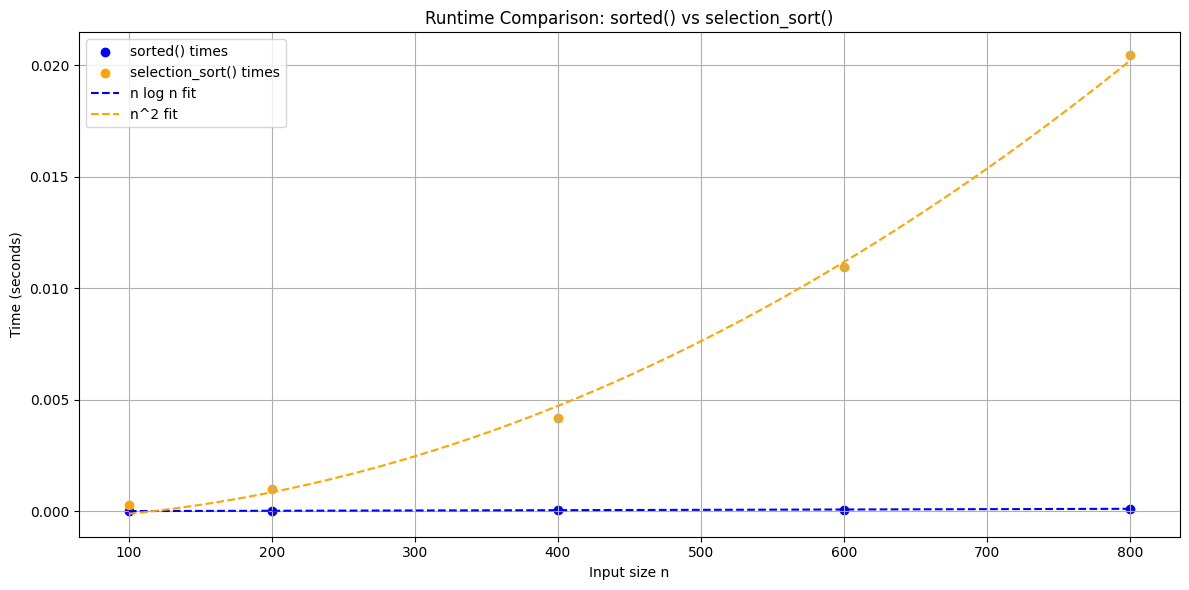

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import random

# --- SELECTION SORT IMPLEMENTATION ---
def selection_sort(arr):
    n = len(arr)
    for i in range(n):
        min_idx = i
        for j in range(i + 1, n):
            if arr[j] < arr[min_idx]:
                min_idx = j
        arr[i], arr[min_idx] = arr[min_idx], arr[i]

# --- INPUT SIZES ---
input_sizes = [100, 200, 400, 600, 800]  # Keep small to avoid long runtimes for selection sort

# --- RUNTIME MEASUREMENT ---
times_sorted = []
times_selection = []

for n in input_sizes:
    data = [random.random() for _ in range(n)]

    # Measure built-in sorted()
    start = time.perf_counter()
    sorted(data)
    end = time.perf_counter()
    times_sorted.append(end - start)

    # Measure selection sort
    data_copy = data.copy()
    start = time.perf_counter()
    selection_sort(data_copy)
    end = time.perf_counter()
    times_selection.append(end - start)

# --- MODEL FUNCTIONS ---
def n_log_n_model(n, a, b):
    return a * n * np.log(n) + b

def n_squared_model(n, a, b):
    return a * n**2 + b

# --- CURVE FITTING ---
input_array = np.array(input_sizes)
sorted_array = np.array(times_sorted)
selection_array = np.array(times_selection)

params_sorted, _ = curve_fit(n_log_n_model, input_array, sorted_array)
params_selection, _ = curve_fit(n_squared_model, input_array, selection_array)

# --- PRINT FITTED MODELS ---
a_sort, b_sort = params_sorted
a_sel, b_sel = params_selection

print(f"sorted(): T(n) ≈ {a_sort:.8f} * n * log(n) + {b_sort:.8f}")
print(f"selection_sort(): T(n) ≈ {a_sel:.8f} * n^2 + {b_sel:.8f}")

# --- PLOTTING ---
plt.figure(figsize=(12, 6))
n_fine = np.linspace(min(input_sizes), max(input_sizes), 500)

# Plot measured data
plt.scatter(input_sizes, times_sorted, label="sorted() times", color='blue')
plt.scatter(input_sizes, times_selection, label="selection_sort() times", color='orange')

# Plot fitted curves
plt.plot(n_fine, n_log_n_model(n_fine, *params_sorted), color='blue', linestyle='--', label="n log n fit")
plt.plot(n_fine, n_squared_model(n_fine, *params_selection), color='orange', linestyle='--', label="n^2 fit")

plt.xlabel("Input size n")
plt.ylabel("Time (seconds)")
plt.title("Runtime Comparison: sorted() vs selection_sort()")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

